In [54]:
import numpy as np
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import Ridge
import shap
import torch
from models_transformer import SingleOutTransformerNet
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [37]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_data = np.load("data_processed/test_data_scaled.npz")
X_test = test_data["x"]    
y_test = test_data["age"]    

In [38]:
NUM_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]

In [40]:
IN_DIM = X_test.shape[1]

EMB_DIM = 64
NHEAD = 4
# NUM_LAYERS = 11
FF_DIM = 128
DROPOUT = 0.1

predictions = {}

for layer in NUM_LAYERS:
    
    model = SingleOutTransformerNet(IN_DIM, emb_dim=EMB_DIM, nhead=NHEAD, 
                                    num_layers=layer, ff_dim=FF_DIM, 
                                    dropout=DROPOUT).to(DEVICE)
    
    state_dict = torch.load(f"trained_models/{layer}layers/TR_model_{layer}layers.pt")
    model.load_state_dict(state_dict)
    
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    
    with torch.no_grad():
        y_pred_full = model(X_test_tensor)
        y_pred_full = y_pred_full.squeeze(-1)
    
    y_pred_full = y_pred_full.cpu().numpy()

    predictions[f"{layer}layers"] = y_pred_full

In [51]:
N, d = X_test.shape

roll = {}
z_roll = {}
r2_roll = {}
ridges = {}
predictions_roll = {}
for layer in NUM_LAYERS:
    results_rollout = np.load(f"Results/rollout_local/{layer}layers/rollout{layer}layers.npz")

    R_test = results_rollout['rollout']
    Z_rollout = np.einsum("nij,nj->ni", R_test, X_test)

    ridge = Ridge(alpha=1e-3, fit_intercept=True)
    ridge.fit(Z_rollout, y_pred_full)

    beta = ridge.coef_
    intercept = ridge.intercept_

    y_pred_rollout = ridge.predict(Z_rollout)
    y_pred_residual = predictions[f"{layer}layers"] - y_pred_rollout

    # Variance explained by rollout-mediated surrogate
    r2_rollout = 1.0 - np.sum((y_pred_full - y_pred_rollout)**2) / np.sum((y_pred_full - y_pred_full.mean())**2)
    
    roll[f"{layer}layers"] = R_test
    z_roll[f"{layer}layers"] = Z_rollout
    r2_roll[f"{layer}layers"] = r2_rollout
    ridges[f"{layer}layers"] = ridge
    predictions_roll[f"{layer}layers"] = y_pred_rollout

In [44]:
# ------------------------------------------------------------
# 3. Define models for SHAP
# ------------------------------------------------------------
def model_g(X):
    """
    Rollout-mediated surrogate.
    Here we need R(x). Since R is available only for X_test,
    this function assumes SHAP is evaluated on rows from X_test.
    """
    # Match rows of X to X_test by exact equality.
    # This is safe if SHAP is called only on subsets of X_test.
    preds = []
    for x in X:
        idx = np.where(np.all(np.isclose(X_test, x, atol=1e-8), axis=1))[0][0]
        z = R_test[idx] @ x
        preds.append(intercept + beta @ z)
    return np.array(preds)


def model_e(X):
    """
    Residual model e(x)=f(x)-g(x), evaluated on X_test rows.
    """
    preds = []
    for x in X:
        idx = np.where(np.all(np.isclose(X_test, x, atol=1e-8), axis=1))[0][0]
        preds.append(y_pred_residual[idx])
    return np.array(preds)


def model_f_values(X):
    """
    Full transformer predictions already computed on X_test.
    """
    preds = []
    for x in X:
        idx = np.where(np.all(np.isclose(X_test, x, atol=1e-8), axis=1))[0][0]
        preds.append(y_pred_full[idx])
    return np.array(preds)

In [46]:
# ------------------------------------------------------------
# 4. Compute SHAP values
# ------------------------------------------------------------

# Use a smaller background/sample for speed
rng = np.random.default_rng(0)
shap_G = {}

for layer in NUM_LAYERS:
    z_rollout = z_roll[f"{layer}layers"]
    ridge = ridges[f"{layer}layers"]
    
    background_idx = rng.choice(len(z_rollout), size=100, replace=False)
    sample_idx = rng.choice(len(z_rollout), size=X_test.shape[0], replace=False)

    z_background = z_rollout[background_idx]
    z_sample = z_rollout[sample_idx]

    # SHAP explainer
    explainer_g = shap.LinearExplainer(ridge, z_background)

    # SHAP values
    shap_g = explainer_g.shap_values(z_sample)

    shap_G[f"{layer}layers"] = shap_g

    # Global importance
    # I_g = np.mean(np.abs(shap_g), axis=0)

In [26]:
shap_f_loader = np.load(f"Results/shap_values/values/{layer}layers/shap_values_{layer}layers.npz")
shap_f = shap_f_loader["shap_vals"]

In [52]:
corr_fg_pear = []
corr_fg_spear = []
r2_fg = []

for layer in NUM_LAYERS:
    shap_f_loader = np.load(f"Results/shap_values/values/{layer}layers/shap_values_{layer}layers.npz")
    shap_f = shap_f_loader["shap_vals"]

    shap_e = shap_f - shap_G[f"{layer}layers"]

    I_f = np.mean(np.abs(shap_f), axis=0)
    I_g = np.mean(np.abs(shap_g), axis=0)
    I_e = np.mean(np.abs(shap_e), axis=0)

    # Agreement between full SHAP and rollout-mediated SHAP
    pearson_fg = pearsonr(I_f, I_g)[0]
    spearman_fg = spearmanr(I_f, I_g).correlation

    y_pred_full = predictions[f"{layer}layers"]
    y_pred_rollout = predictions_roll[f"{layer}layers"]
    
    r2_rollout = r2_score(y_pred_full, y_pred_rollout)


    # print("Pearson corr SHAP(f) vs SHAP(g):", pearson_fg)
    # print("Spearman corr SHAP(f) vs SHAP(g):", spearman_fg)

    corr_fg_pear.append(pearson_fg)
    corr_fg_spear.append(spearman_fg)
    r2_fg.append(r2_rollout)

# Build matrix
heatmap_data = np.array([corr_fg_pear, corr_fg_pear, r2_fg])

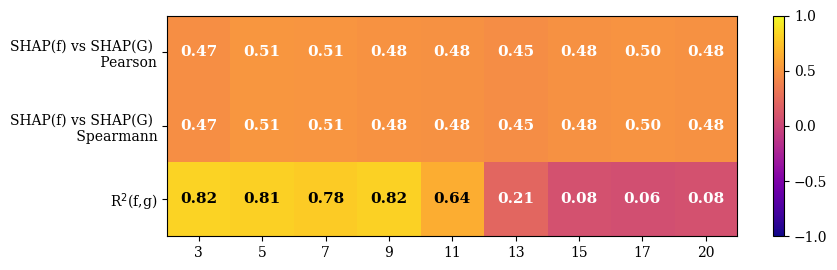

In [63]:
plt.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(9, 2.8))
cmap = "plasma"

im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, 
               vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(range(len(NUM_LAYERS)))
ax.set_xticklabels(NUM_LAYERS)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["SHAP(f) vs SHAP(G) \n Pearson", 
                    "SHAP(f) vs SHAP(G) \n Spearmann", 
                    r"R$^2$(f,g)"])

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):

        value = heatmap_data[i, j]

        # choose text color depending on intensity
        text_color = "white" if abs(value) < 0.6 else "black"

        ax.text(j, i, f"{value:.2f}", 
                ha="center", va="center", 
                fontsize=11, fontweight="bold",
                color=text_color)

cbar = plt.colorbar(im)
# cbar.set_label("Spearman correlation")
# ax.set_xlabel("Transformer depth L")

plt.tight_layout()

plt.savefig("Results/feature_importance_plots/shap_heatmap.pdf", bbox_inches="tight")
plt.show()

In [28]:
import numpy as np
from sklearn.metrics import r2_score

# y_pred_full      : predictions of the full transformer f(x)
# y_pred_rollout   : predictions of the rollout surrogate g(x)

r2_rollout = r2_score(y_pred_full, y_pred_rollout)

print("Variance explained by rollout surrogate R^2(g,f):")
print(r2_rollout)

Variance explained by rollout surrogate R^2(g,f):
0.6389989852905273
